# Build GNNs with Pytorch 
Using the esol_modified.csv data set to predict logP from structure

In [3]:
import math
import numpy
import pandas as pd
from pathlib import Path
import os
from rdkit import Chem

import torch
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
from torch_geometric.nn import GCNConv, GINConv, GATConv
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, global_add_pool
from torch_geometric.data import Data

First, load the esol data set from session11

In [4]:
df = pd.read_csv(os.path.join("..", "..", "session11", "material", "esol_modified.csv")).dropna(subset=["SMILES"])
# we will have trouble if the SMILES contains only a single atom (no graph can be constructed)
df = df.loc[df.SMILES != 'C']


Next, we encode the SMILES in the dataset into graph objects using RDKit

In [5]:
def atom_features(atom): # Create a tensor for atom features, length = 5
    return torch.tensor([
        atom.GetAtomicNum(),
        atom.GetTotalDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
    ], dtype=torch.float)

def bond_features(bond): # Create a tensor for bond features, length = 6
    bt = bond.GetBondType()
    return torch.tensor([
        bt == Chem.rdchem.BondType.SINGLE,
        bt == Chem.rdchem.BondType.DOUBLE,
        bt == Chem.rdchem.BondType.TRIPLE,
        bt == Chem.rdchem.BondType.AROMATIC,
        bond.GetIsConjugated(),
        bond.IsInRing(),
    ], dtype=torch.float)

In [6]:
def smiles_to_graph(smiles, y):
    mol = Chem.MolFromSmiles(smiles) # Create a RDKit mol object from the smiles

    # Calculate atom features for all atoms in the molecule
    x = torch.stack([atom_features(atom) for atom in mol.GetAtoms()], dim=0)

    # Edges
    edge_index = []
    edge_attr = []
    
    # Iterate through all bonds in the molecule
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        # Represent molecule as an undirected graph --> add both directions, GNN does not know about directionality of edges in molecules
        edge_index.append([i, j]) # left to right
        edge_index.append([j, i]) # right to left

        bf = bond_features(bond) # calculate bond features 
        edge_attr.append(bf)
        edge_attr.append(bf) # add two times, once for forward and once for backwards edge

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous() 
    edge_attr  = torch.stack(edge_attr, dim=0)

    # Target property: logP
    y = torch.tensor([y], dtype=torch.float)
    
    # x: atom stack, y: logP
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

Obtain Graph representation of the data

In [7]:
graphs = [smiles_to_graph(row.SMILES, row.LogP) for _, row in df.iterrows()]

In [8]:
# Graph Convolutional Network (GCN)
class GCNModel(torch.nn.Module):
    def __init__(self, dim_h=64): # dim_h: Size of hidden layer
        super().__init__()
        self.conv1 = GCNConv(5, dim_h) # first convolution layer: in_channels: 5, number of atom features
        self.conv2 = GCNConv(dim_h, dim_h) # second convolution layer
        self.lin = torch.nn.Linear(dim_h, 1) # output layer
        
    # Define how the data flows through the layers
    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))  # input layer: convolution + activation function (ReLu)
        x = torch.relu(self.conv2(x, edge_index))  # hidden layer: convolution + activation function (ReLu)
        x = global_mean_pool(x, batch)             # pooling function
        return self.lin(x).squeeze(-1)


In [9]:
# Graph Isomorphism Network (GIN)
class GINModel(torch.nn.Module):
    def __init__(self, dim_h=64):
        super().__init__()

        nn1 = torch.nn.Sequential(
            torch.nn.Linear(5, dim_h),
            torch.nn.ReLU(),
            torch.nn.Linear(dim_h, dim_h)
        )
        nn2 = torch.nn.Sequential(
            torch.nn.Linear(dim_h, dim_h),
            torch.nn.ReLU(),
            torch.nn.Linear(dim_h, dim_h)
        )

        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)

        self.lin = torch.nn.Linear(dim_h, 1)

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch) # try: global_add_pool(x, batch)
        return self.lin(x).squeeze(-1)


In [10]:
# Graph Attention Network (GAT)
class GATModel(torch.nn.Module):
    def __init__(self, dim_h=64, heads=4):
        super().__init__()

        # Input layer
        self.conv1 = GATConv(
            in_channels=5,        # your atom feature size
            out_channels=dim_h,  # hidden dimension per head
            heads=heads,
            dropout=0.1,
            concat=True           # concatenates heads --> output = hidden * heads
        )

        # Second layer
        self.conv2 = GATConv(
            in_channels=dim_h * heads,
            out_channels=dim_h,
            heads=1,
            dropout=0.1,
            concat=False          # final output shape = (hidden,)
        )

        self.lin = torch.nn.Linear(dim_h, 1)

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x).squeeze(-1)


In [11]:
def train(model, train_loader, val_loader, epochs=20, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # lr: learning rate
    criterion = torch.nn.MSELoss() # loss function

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for batch in train_loader:
            optimizer.zero_grad() # Reset gradients
            pred = model(batch.x, batch.edge_index, batch.batch) # predict on batch
            loss = criterion(pred, batch.y) # define criterion
            loss.backward() # computes the gradient of the loss
            optimizer.step() # Perform an optimization step
            train_losses.append(loss.item())

        val_loss = evaluate(model, val_loader) # evaluate re-trained model on validation data

        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss = {sum(train_losses)/len(train_losses):.4f} | " # average train loss
              f"Val Loss = {val_loss:.4f}") 


def test(model, test_loader):
    test_loss = evaluate(model, test_loader)
    print(f"\nTest Loss: {test_loss:.4f}")


In [12]:
def create_splits(graphs, train_ratio=0.8, val_ratio=0.1, seed=42):
    torch.manual_seed(seed)
    graphs = graphs.copy()
    permutation = torch.randperm(len(graphs))
    graphs = [graphs[i] for i in permutation]

    n = len(graphs)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_graphs = graphs[:n_train]
    val_graphs   = graphs[n_train:n_train + n_val]
    test_graphs  = graphs[n_train + n_val:]

    return train_graphs, val_graphs, test_graphs

train_graphs, val_graphs, test_graphs = create_splits(graphs)

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=32)
test_loader  = DataLoader(test_graphs, batch_size=32)


In [13]:
def evaluate(model, loader):
    model.eval()
    criterion = torch.nn.MSELoss()
    losses = []

    with torch.no_grad():
        for batch in loader:
            pred = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(pred, batch.y)
            losses.append(loss.item())

    return sum(losses) / len(losses)

Now, we load the data and train the GNNs

In [14]:
loader = DataLoader(graphs, batch_size=100, shuffle=True)

In [15]:
# training GCN for 10 epochs
gcn = GCNModel()
gin = GINModel()
gat = GATModel()

epochs = 10

print("\n=== Training GCN ===")
train(gcn, train_loader, val_loader, epochs=epochs)
test(gcn, test_loader)

print("\n=== Training GIN ===")
train(gin, train_loader, val_loader, epochs=epochs)
test(gin, test_loader)

print("\n=== Training GAT ===")
train(gat, train_loader, val_loader, epochs=epochs)
test(gat, test_loader)


=== Training GCN ===
Epoch 01 | Train Loss = 4.8751 | Val Loss = 4.9053
Epoch 02 | Train Loss = 3.5262 | Val Loss = 5.0110
Epoch 03 | Train Loss = 3.3358 | Val Loss = 4.9413
Epoch 04 | Train Loss = 3.2646 | Val Loss = 4.9624
Epoch 05 | Train Loss = 3.2506 | Val Loss = 4.9107
Epoch 06 | Train Loss = 3.3386 | Val Loss = 4.9357
Epoch 07 | Train Loss = 3.1291 | Val Loss = 4.9323
Epoch 08 | Train Loss = 3.0905 | Val Loss = 4.7502
Epoch 09 | Train Loss = 3.0206 | Val Loss = 4.8516
Epoch 10 | Train Loss = 3.1375 | Val Loss = 4.8472

Test Loss: 2.3247

=== Training GIN ===
Epoch 01 | Train Loss = 3.3526 | Val Loss = 4.2662
Epoch 02 | Train Loss = 2.9563 | Val Loss = 4.4150
Epoch 03 | Train Loss = 2.8788 | Val Loss = 4.3145
Epoch 04 | Train Loss = 2.9782 | Val Loss = 4.2581
Epoch 05 | Train Loss = 2.8053 | Val Loss = 4.4130
Epoch 06 | Train Loss = 2.8297 | Val Loss = 4.0971
Epoch 07 | Train Loss = 2.7414 | Val Loss = 3.9033
Epoch 08 | Train Loss = 2.6146 | Val Loss = 3.8591
Epoch 09 | Train Lo

In [16]:
import matplotlib.pyplot as plt
def parity_plot(model, test_loader, title="Parity Plot (Test Set)"):
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for batch in test_loader:
            pred = model(batch.x, batch.edge_index, batch.batch)

            # Ensure correct shapes
            pred = pred.view(-1).cpu()
            y = batch.y.view(-1).cpu()

            preds.append(pred)
            trues.append(y)

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    # Parity plot
    plt.figure(figsize=(5,5))
    plt.scatter(trues, preds, alpha=0.6)
    plt.plot([trues.min(), trues.max()],
             [trues.min(), trues.max()],
             color='red', linestyle='--', linewidth=2)

    plt.xlabel("True logP")
    plt.ylabel("Predicted logP")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Usage:

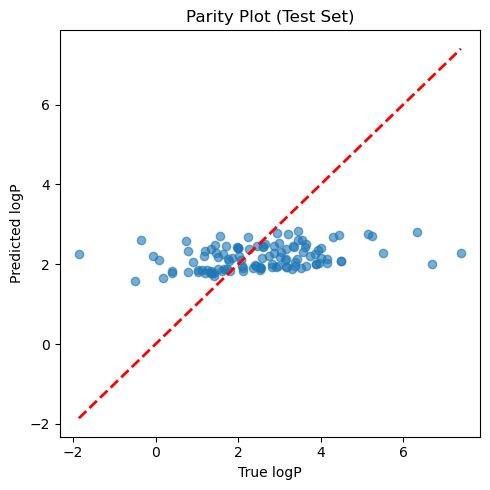

In [17]:
parity_plot(gcn, test_loader)

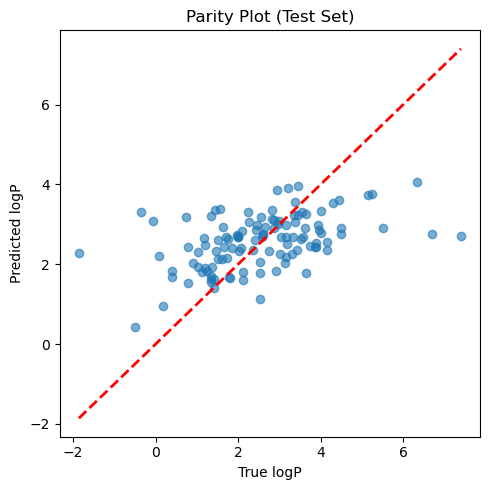

In [18]:
parity_plot(gin, test_loader)

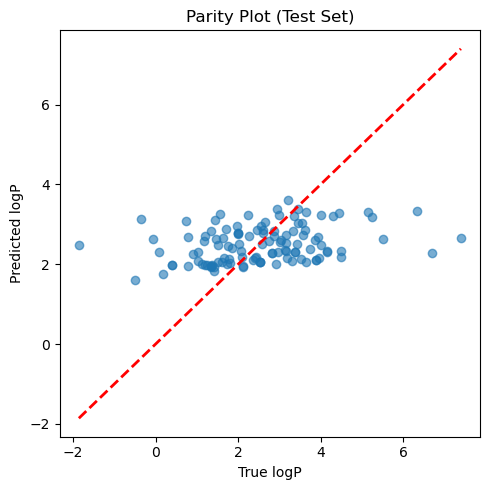

In [19]:
parity_plot(gat, test_loader)

In [20]:
import numpy as np

In [21]:
np.__version__

'1.26.4'